# Year 5 Pipeline - restarting the exosearch 
### Notes:
- Year: Year 5, chosen for it's overlapping sectors in the CVZ as seen by the MIT graph 
- Sectors: S61-S69

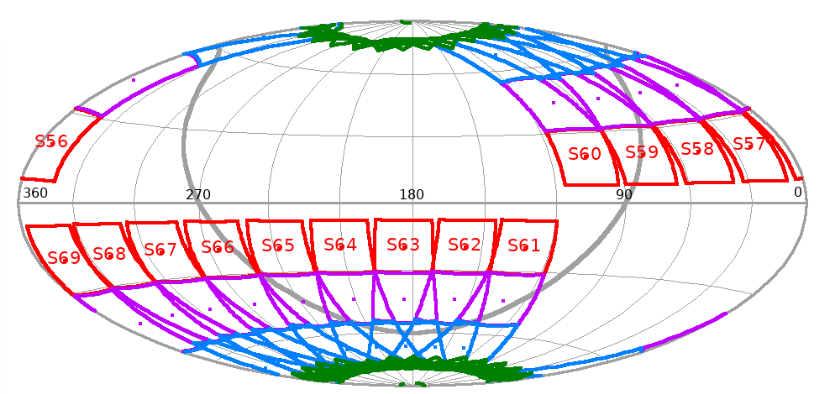




### Steps:
1. Run download_lists.sh to get a list of candidate targets in the chosen sectors.

2. Get the persistent TIC's across all 9 sectors (the targets which have continuous observations across all sectors).

3. Download the CBV (Co-trending basis vector) files for sectors 61-69 in BASH, you should get files like "tesscurl_sector_61_cbv.sh". These files are the systematic noise patterns from TESS.

4. Download the CBV FITS files - Same as CBV files above but in FITS format. You should get files like "tess2023043185947-s0062-1-4-0245-s_cbv.fits" which represent tess{timestamp}-s{sector:04d}-{cam}-{ccd}-{version}-s_cbv.fits.

5. Get the cadence bounds for sectors 61-69 from the CBV FITS Files.

6. Run vector_matrix.py in BASH using info_y5.py. You should get files like " evec_matrix_69_4_4.p".

7. Run the vector matrix code to generate the even matrices from the CBV Fits files.

8. Run the light curve download script (download_lc_y5.py).


### Note:
- Only year 5 was chosen for the rerun due to the consecutive nature of the search - this can be reperformed for other sectors, years, etc. 
- Use Python global environment (Python 3.12.3)
- TIC = TESS Input Catalog - catalog of stars that TESS uses to select which stars to observe
- TID (what I use, not official) - TIC ID number - every star in the catalog gets a unique TID number (ex: TIC 219879302)

### Numbers:
- Persistent tics 1299
- CBV FITS Files = 368 (9 Sectors x 16 Camera/CCD combinations - some may have multiples)


### Required software:
- lightkurve package

In [10]:
# util information

year = 5
sectors = [61, 69]
cadence_bounds = {
    61: (1249444, 1267755),
    62: (1267906, 1286422),
    63: (1286574, 1305680),
    64: (1305831, 1325215),
    65: (1325721, 1345805),
    66: (1346554, 1367260),
    67: (1367411, 1387397),
    68: (1387549, 1407372),
    69: (1407524, 1426092)
}

In [8]:
# imports 
import pandas as pd
from astropy.io import fits
import glob


In [5]:
# Step 2 - get persistent TICS across all 9 sectors

# get a list of ALL tic ids
all_tids_set = []
for i in range(61, 70):
    table_file = f"/home/juliajos/TESS/data/light_curves/info/all_targets_S0{i}_v1.txt"  # downloaded using download_lists.sh
    data = pd.read_csv(table_file, comment='#', delimiter='\t')
    tids = set(data.iloc[:,0])
    all_tids_set.append(tids)

# get the tids that are persistent across all 9 sectors
common_tics = set.intersection(*all_tids_set)
print(f"Persistent TICs in sectors 61-69: {len(common_tics)}")

# save persistent tics to a file
with open("/home/juliajos/TESS/data/light_curves/info/persistant_tids_y5.txt", "w") as f:
    for tid in sorted(common_tics):
        f.write(f"{tid}\n")


Persistent TICs in sectors 61-69: 1299


In [6]:
# Step 3 - download the CBV files for sectors 61-69 in BASH

In [7]:
# Step 4 - download the CBV FITS files in BASH

In [9]:
# Step 5 - Get the cadence bounds from the CBV FITS files

for sector in range(61, 70):
    pattern = f'/home/juliajos/TESS/data/light_curves/info/cbvs/*s{sector:04d}*1-1*.fits'
    files = glob.glob(pattern)
    if files:
        with fits.open(files[0]) as hdu:
            cadences = hdu[1].data['CADENCENO']
            print(f"sector {sector}: ({cadences.min()}, {cadences.max()})")
    else:
        print(f"sector {sector}: no file found")

sector 61: (1249444, 1267755)
sector 62: (1267906, 1286422)
sector 63: (1286574, 1305680)
sector 64: (1305831, 1325215)
sector 65: (1325721, 1345805)
sector 66: (1346554, 1367260)
sector 67: (1367411, 1387397)
sector 68: (1387549, 1407372)
sector 69: (1407524, 1426092)


In [ ]:
# Step 6 - Run vector_matrix.py in BASH